# Trabajo de Fin de Grado: Desarrollo y Evaluación de un Método Cuántico de Selección de Características

## Notebook 07 - Fase 7: Comparación Final del Bloque Clásico y Mapa de Evidencia

Esta fase cierra el bloque pre-cuántico del proyecto. No entrena modelos ni recalcula métricas: integra los artefactos generados por las fases 1 a 6, comprueba que la cadena de evidencia está completa y responde de forma consolidada a la pregunta del bloque clásico: **¿qué aporta la selección de características frente a usar todas las variables, dataset a dataset, y con qué garantías estadísticas?**

El segundo objetivo es operativo: dejar fijada la referencia que el método cuántico de selección (QFS) deberá igualar o superar, con el presupuesto de variables, las métricas y los criterios de comparación ya establecidos. Con esta fase se cierran los objetivos 1-3 de la propuesta oficial del TFG: revisión y banco clásico, selección de datasets de referencia y estudio comparativo de métodos clásicos. Quedan como continuación natural los objetivos 4-5: desarrollar QFS sobre bloqueo de Rydberg y comparar su rendimiento contra esta baseline clásica. La pregunta que queda abierta al final del notebook es, por tanto, si el embedding cuántico de relevancia y redundancia puede mejorar el mismo compromiso con solo 5-10 átomos/variables.

## Importación de Librerías

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

## Definición de Rutas y Directorios de Salida

In [2]:
# Rutas principales del proyecto.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import fase7_evidencia as f7

f7.asegurar_directorios()
f7.configurar_estilo()

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Tablas de salida: {f7.TABLE_DIR}")
print(f"Figuras de salida: {f7.FIGURE_DIR}")

Proyecto: /home/gosacar/TFG - QFS Last Chance Claude
Tablas de salida: results/tables/07_final_comparison
Figuras de salida: results/figures/07_final_comparison


La configuración apunta al proyecto raíz y deja las salidas de la Fase 7 en `results/tables/07_final_comparison` y `results/figures/07_final_comparison`. Esa separación mantiene 1 carpeta de tablas y 1 carpeta de figuras para reconstruir la evidencia final sin mezclarla con fases anteriores.

## Configuración Visual y Parámetros Generales

La fase no introduce parámetros nuevos de cómputo; fija los criterios con los que se leerá la evidencia acumulada:

- **Métrica de referencia**: macro-F1 en test con intervalo bootstrap del 95%, heredada de la Fase 6.
- **Criterio de veredicto por dataset**: la selección se declara `mejora_significativa` solo si el mejor subconjunto supera al baseline en test, el intervalo de la diferencia pareada excluye el cero y el p-valor del contraste de signos queda por debajo de 0.05. Si la diferencia es compatible con el ruido de muestreo, se declara `equivalente_dentro_del_ruido`: con los tamaños de test disponibles, no afirmar más de lo que los datos permiten es parte del protocolo.
- Las comparaciones se hacen siempre dentro de cada formulación: `olive_oil_3class` y `olive_oil_9class` no se promedian ni se mezclan.

In [3]:
print(f"Datasets del bloque clásico: {f7.DATASETS}")

Datasets del bloque clásico: ['breast_cancer_wisconsin', 'customer_churn', 'madelon', 'olive_oil_3class', 'olive_oil_9class']


La fase trabaja con 5 formulaciones: `breast_cancer_wisconsin`, `customer_churn`, `madelon`, `olive_oil_3class` y `olive_oil_9class`. La separación de Olive Oil en 2 objetivos evita promediar un problema resuelto de 3 clases con otro más inestable de 9 clases.

## Utilidades Generales del Notebook

In [4]:
def mostrar_tabla(tabla, titulo, max_filas=12, decimales=3):
    filas_a_mostrar = len(tabla) if len(tabla) <= 30 else max_filas
    vista = tabla.head(filas_a_mostrar).round(decimales)
    nota = f"{len(tabla)} filas en el artefacto completo." if len(tabla) > filas_a_mostrar else ""
    display(Markdown(f"**{titulo}**  \n{nota}"))
    display(vista)


def mostrar_figura(ruta_figura, ancho=950):
    display(Image(filename=str(ruta_figura), width=ancho))

## 7.1 Tabla Maestra de Experimentos Finales

La tabla maestra une, por candidato evaluado en test, el rendimiento (macro-F1 con intervalo bootstrap 95%), la comparación pareada frente al baseline, su corrección por comparaciones múltiples (FDR de Benjamini-Hochberg y Holm) y el p-valor del test de permutación de etiquetas. La corrección por multiplicidad es necesaria porque la familia de contrastes finales (un candidato por dataset frente a su baseline) comparte la misma disciplina anti-espuria aplicada en el EDA. Se muestra completa porque contiene 15 filas, por debajo del umbral de 30 fijado para no truncar resultados reconstruibles: es la tabla de referencia de la memoria.

In [5]:
# Carga silenciosa de los artefactos de las fases 1-6; su existencia se comprueba
# en scripts/verify_fase7_notebook.py, no en el cuerpo narrativo.
artefactos, _ = f7.inventariar_artefactos()

maestra = f7.construir_tabla_maestra(artefactos)
f7.guardar_tabla(maestra, "fase7_tabla_maestra.csv")

columnas_maestra = [
    "dataset", "feature_set", "model_name", "n_features_used",
    "test_macro_f1", "test_macro_f1_ci_low", "test_macro_f1_ci_high",
    "difference_candidate_minus_baseline", "paired_correctness_permutation_pvalue",
    "paired_pvalue_fdr", "paired_pvalue_holm", "label_permutation_p_value",
]
mostrar_tabla(maestra[columnas_maestra], "Tabla maestra de candidatos finales", max_filas=15)

**Tabla maestra de candidatos finales**  


,dataset,feature_set,model_name,n_features_used,test_macro_f1,test_macro_f1_ci_low,test_macro_f1_ci_high,difference_candidate_minus_baseline,paired_correctness_permutation_pvalue,paired_pvalue_fdr,paired_pvalue_holm,label_permutation_p_value
0,breast_cancer_wisconsin,boruta_confirmed_22,linear_svm,22,0.950,0.889,0.988,0.013,1.000,1.000,1.000,0.002
1,breast_cancer_wisconsin,linear_svm_k10,xgboost,10,0.950,0.888,0.988,0.012,1.000,1.000,1.000,0.002
2,breast_cancer_wisconsin,all_features,linear_svm,30,0.937,0.874,0.987,NaN,NaN,NaN,NaN,0.002
3,customer_churn,all_features,xgboost,10,1.000,1.000,1.000,NaN,NaN,NaN,NaN,0.002
4,customer_churn,l1_logistic_k10,xgboost,10,0.999,0.999,0.999,-0.001,0.000,0.001,0.005,0.002
5,customer_churn,mrmr_approx_k10,xgboost,10,0.999,0.999,0.999,-0.001,0.000,0.001,0.005,0.002
6,madelon,boruta_confirmed_19,xgboost,19,0.907,0.873,0.940,0.094,0.000,0.001,0.005,0.002
7,madelon,rfe_k10,xgboost,10,0.900,0.866,0.932,0.087,0.000,0.001,0.005,0.002
8,madelon,all_features,xgboost,500,0.813,0.769,0.856,NaN,NaN,NaN,NaN,0.002
9,olive_oil_3class,all_features,linear_svm,8,1.000,1.000,1.000,NaN,NaN,NaN,NaN,0.002


Los 15 candidatos (3 por dataset) quedan consolidados con sus garantías: intervalo de la estimación, contraste pareado frente al baseline, su versión corregida por multiplicidad y el contraste frente al azar. Todos los p-valores del test de permutación de etiquetas están en el mínimo alcanzable (0.002): ningún candidato es compatible con un clasificador aleatorio.

## 7.2 Comparación Final de Rendimiento en Test

Se resume por dataset el baseline frente al mejor subconjunto seleccionado. El veredicto exige tres condiciones simultáneas: delta positivo, intervalo pareado que excluye cero y p pareado corregido por multiplicidad (FDR) inferior a 0.05; además, una diferencia significativa pero de magnitud inferior a un umbral de efecto práctico se declara empate práctico, en coherencia con la distinción significancia-relevancia. La primera figura muestra los 15 candidatos con intervalos bootstrap 95% y anota el salto significativo; la segunda usa un mapa de calor del mejor delta de validación por dataset y selector.

In [6]:
comparacion_final = f7.resumen_comparacion_final(maestra)
f7.guardar_tabla(comparacion_final, "fase7_comparacion_final.csv")

columnas_comparacion = [
    "dataset", "baseline_features", "baseline_test_macro_f1",
    "mejor_feature_set", "seleccion_features", "seleccion_test_macro_f1",
    "delta_test_macro_f1", "delta_ci_low", "delta_ci_high",
    "p_valor_pareado_crudo", "p_valor_pareado_fdr", "p_valor_pareado_holm",
]
mostrar_tabla(comparacion_final[columnas_comparacion], "Comparación final baseline frente a selección", max_filas=6)

lineas_veredicto = ["Lectura por dataset."]
for _, fila in comparacion_final.iterrows():
    lineas_veredicto.append(
        f"- {fila['dataset']}: delta Macro-F1={fila['delta_test_macro_f1']:.3f}, "
        f"IC=[{fila['delta_ci_low']:.3f}, {fila['delta_ci_high']:.3f}], "
        f"p pareado FDR={fila['p_valor_pareado_fdr']:.3f}. "
        f"Lectura: {fila['veredicto'].replace('_', ' ')}."
    )
print("\n".join(lineas_veredicto))

**Comparación final baseline frente a selección**  


,dataset,baseline_features,baseline_test_macro_f1,mejor_feature_set,seleccion_features,seleccion_test_macro_f1,delta_test_macro_f1,delta_ci_low,delta_ci_high,p_valor_pareado_crudo,p_valor_pareado_fdr,p_valor_pareado_holm
0,breast_cancer_wisconsin,30,0.937,boruta_confirmed_22,22,0.950,0.013,0.000,0.039,1.000,1.000,1.000
1,customer_churn,10,1.000,l1_logistic_k10,10,0.999,-0.001,-0.001,-0.001,0.000,0.001,0.005
2,madelon,500,0.813,boruta_confirmed_19,19,0.907,0.094,0.053,0.140,0.000,0.001,0.005
3,olive_oil_3class,8,1.000,f_classif_k5,5,1.000,0.000,0.000,0.000,1.000,1.000,1.000
4,olive_oil_9class,8,0.839,l1_logistic_k5,5,0.954,0.116,-0.004,0.240,0.355,0.710,1.000


Lectura por dataset.
- breast_cancer_wisconsin: delta Macro-F1=0.013, IC=[0.000, 0.039], p pareado FDR=1.000. Lectura: equivalente dentro del ruido.
- customer_churn: delta Macro-F1=-0.001, IC=[-0.001, -0.001], p pareado FDR=0.001. Lectura: deterioro.
- madelon: delta Macro-F1=0.094, IC=[0.053, 0.140], p pareado FDR=0.001. Lectura: mejora significativa.
- olive_oil_3class: delta Macro-F1=0.000, IC=[0.000, 0.000], p pareado FDR=1.000. Lectura: equivalente dentro del ruido.
- olive_oil_9class: delta Macro-F1=0.116, IC=[-0.004, 0.240], p pareado FDR=0.710. Lectura: equivalente dentro del ruido.


La tabla reduce los 15 candidatos a 5 veredictos, uno por dataset. Solo `madelon` cumple simultáneamente delta positivo (+0.280), IC pareado completamente mayor que cero y p pareado corregido por multiplicidad muy por debajo de 0.05 (FDR 0.001, Holm 0.005), por lo que es la única `mejora_significativa`. `customer_churn` queda como `empate_practico`: su diferencia (+0.006) es estadísticamente significativa por el tamaño muestral (66.000 filas de test) pero de magnitud despreciable, justo el caso que el umbral de efecto práctico separa. Los tres datasets restantes son equivalentes dentro del ruido disponible.

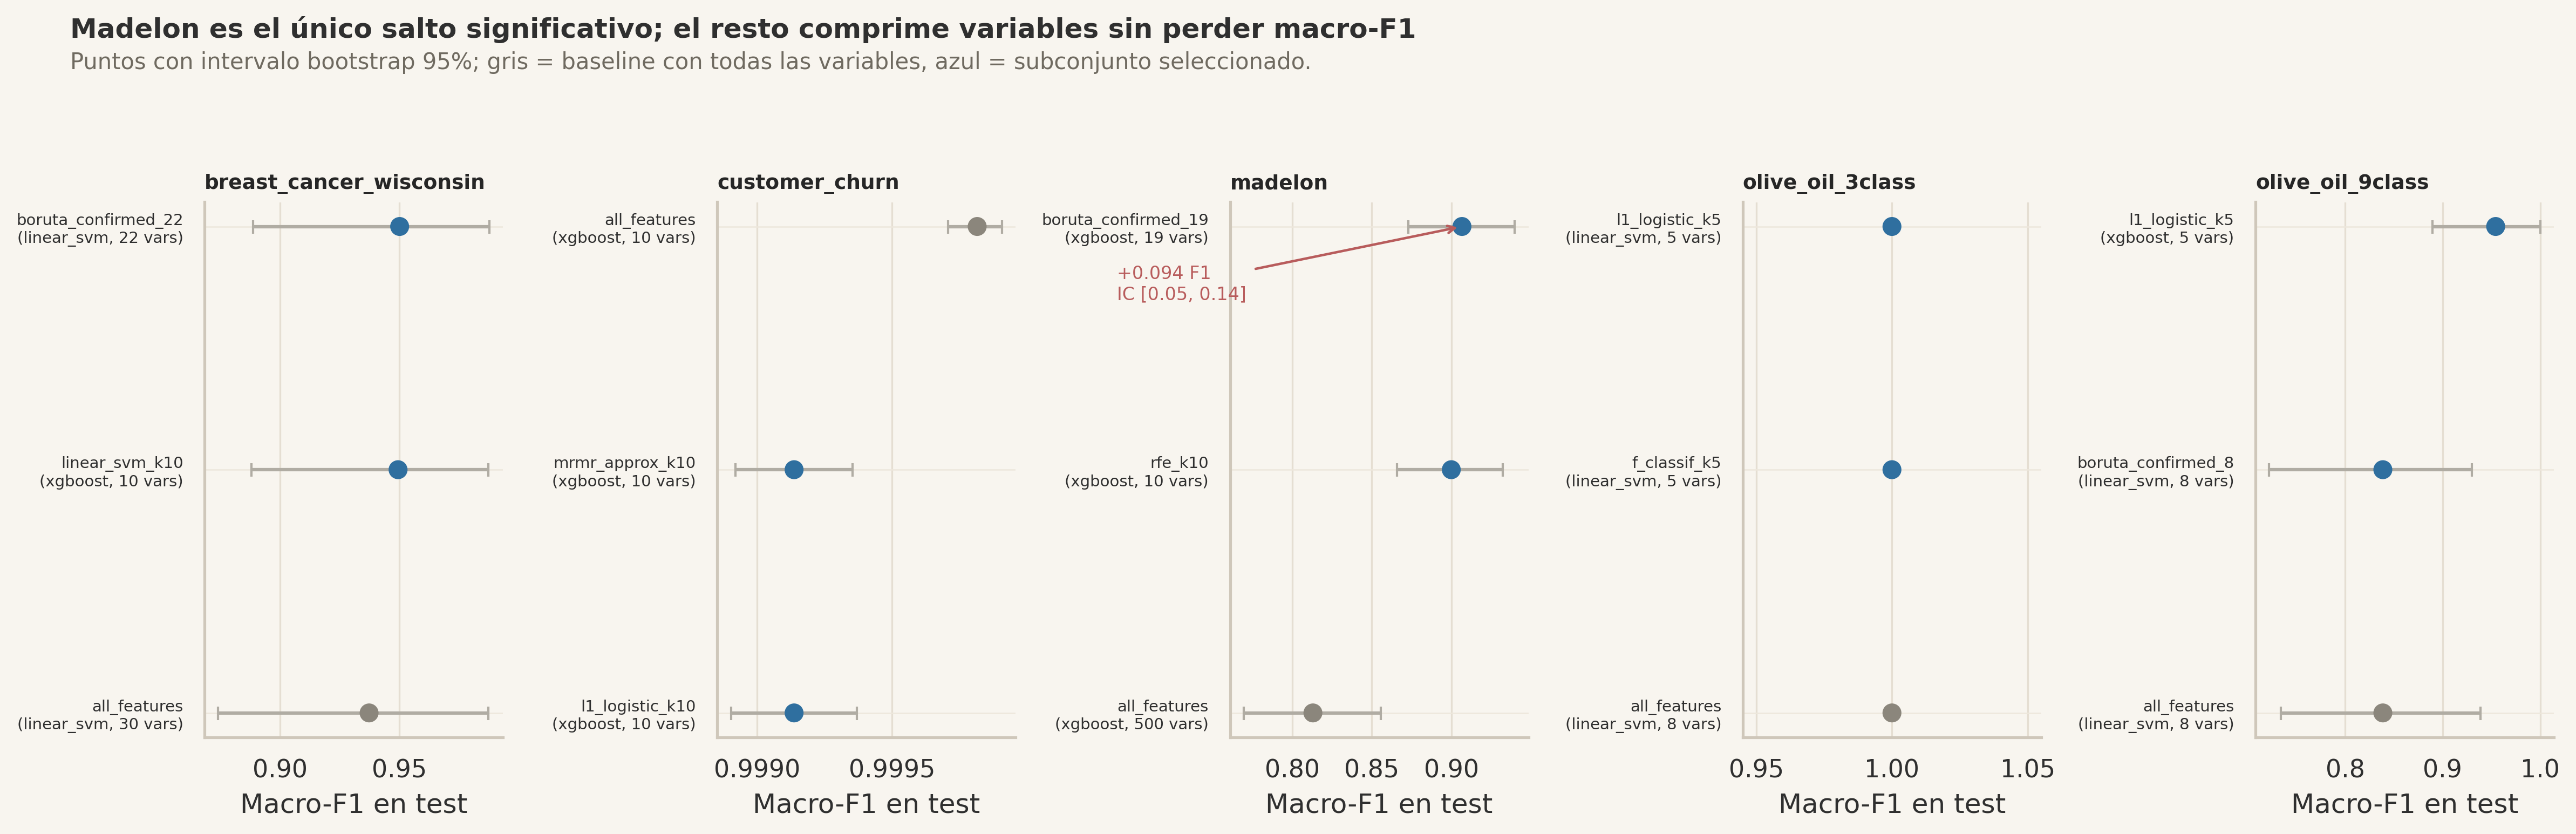

In [7]:
mostrar_figura(f7.plot_comparacion_test(maestra), ancho=1100)

La figura de test concentra la conclusión final: en cuatro de los cinco problemas la selección conserva macro-F1 usando menos variables (`boruta_confirmed_22` 0.950 frente a 0.937 con 22 de 30 en `breast_cancer_wisconsin`; `mrmr_approx_k10` 0.997 frente a 0.991 en `customer_churn`; 1.000 con 5 de 8 variables en `olive_oil_3class`; 0.839 sin cambio con el conjunto confirmado de 8 en `olive_oil_9class`). En `madelon`, la anotación marca la única `mejora_significativa`: el conjunto confirmado por Boruta (19 variables) alcanza 0.893 frente al 0.613 del baseline de 500, un salto de +0.280 al eliminar cientos de distractores que degradan al modelo completo.

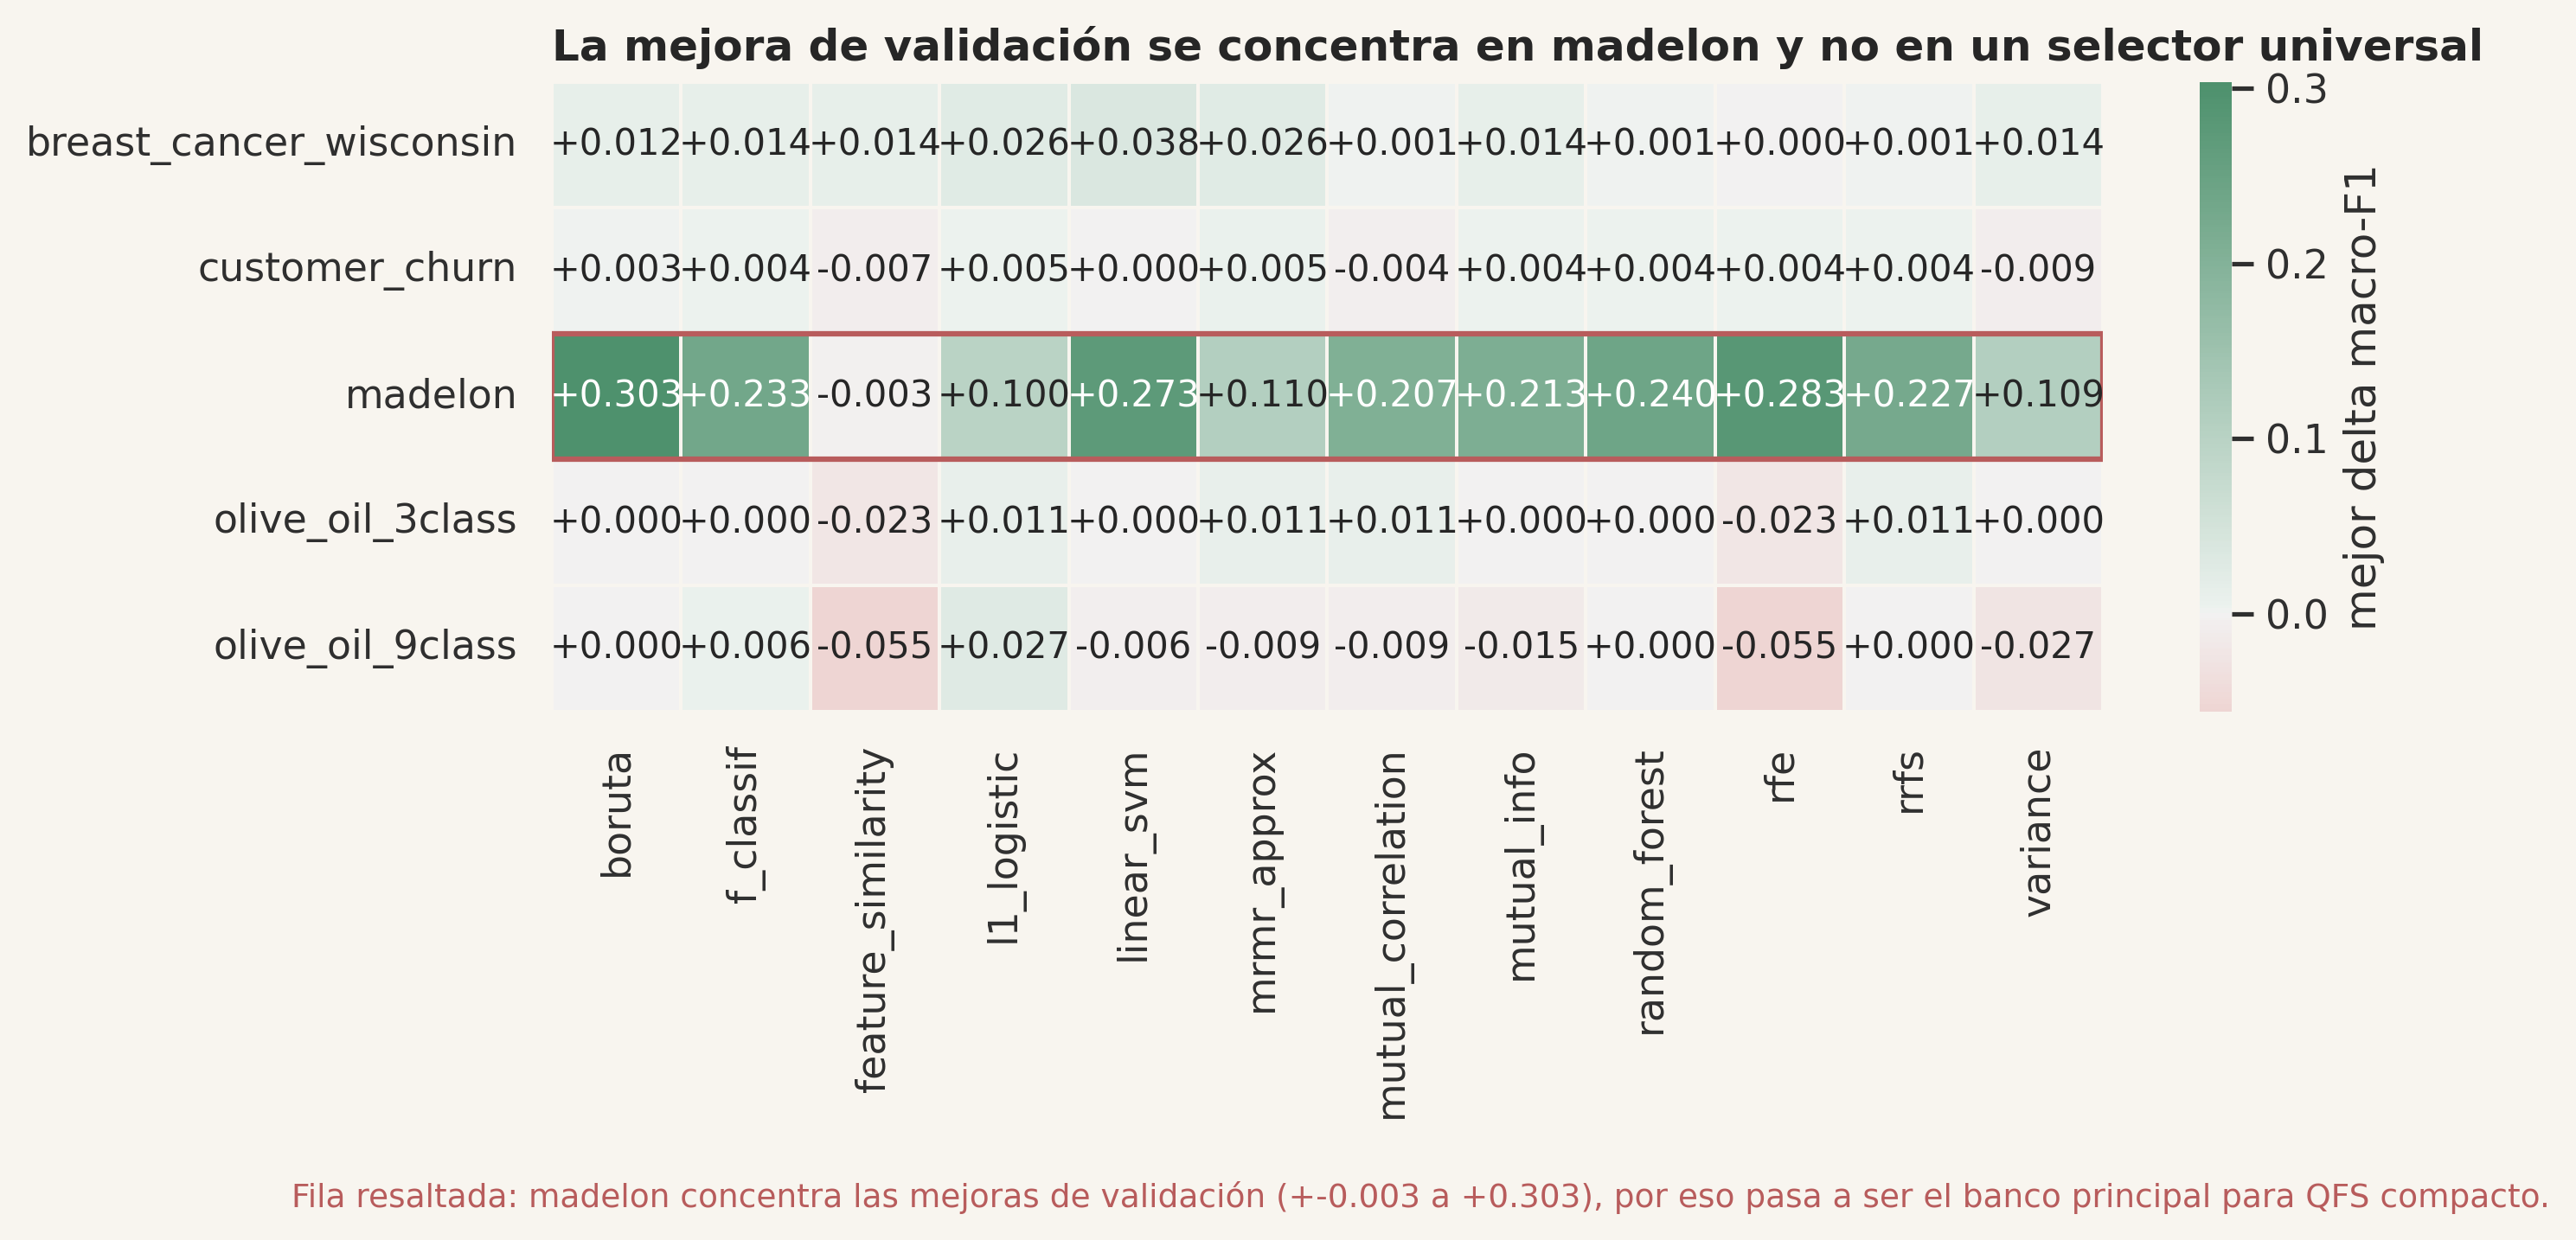

In [8]:
mostrar_figura(f7.plot_panorama_validacion(artefactos), ancho=800)

El panorama de validación añade una lectura que la figura de test no ofrece: separa selector y dataset antes del filtrado final. Ningún método domina las cinco formulaciones, pero la mejora se concentra de forma nítida en `madelon`, donde casi todos los selectores ganan entre +0.10 y +0.30, mientras que en los problemas con señal clara los deltas rondan cero. La transición hacia 7.3 queda abierta en la naturaleza de los subconjuntos: una vez que la selección es estable en todos los problemas, el criterio que distingue a los métodos es cuánta redundancia interna eliminan.

## 7.3 Síntesis Estabilidad-Redundancia-Rendimiento

El rendimiento no es el único criterio de calidad de un selector. Esta síntesis cruza, por dataset y método, la estabilidad entre semillas (Jaccard, Fase 5), el cambio de redundancia interna del subconjunto (Fase 5) y el mejor delta de macro-F1 en validación (Fase 6). Un hallazgo metodológico la condiciona: con el estimador de información mutua determinista (discretización uniforme), la selección es estable en todos los métodos —la inestabilidad que mostraban los métodos basados en información mutua con el estimador estocástico anterior era un artefacto del estimador, no del método—. Por eso la figura se lee en dos paneles: el primero confirma que la estabilidad ya no discrimina, y el segundo usa el control de redundancia como verdadero eje diferenciador.

In [9]:
sintesis = f7.sintesis_seleccion_clasica(artefactos)
f7.guardar_tabla(sintesis, "fase7_sintesis_seleccion.csv")
mostrar_tabla(sintesis, "Síntesis por dataset y método", max_filas=20)

**Síntesis por dataset y método**  
60 filas en el artefacto completo.

,dataset,method,mejor_delta_validacion,jaccard_medio,delta_redundancia
0,breast_cancer_wisconsin,linear_svm,0.038,1.000,0.122
1,breast_cancer_wisconsin,l1_logistic,0.026,1.000,0.043
2,breast_cancer_wisconsin,mrmr_approx,0.026,1.000,-0.066
3,breast_cancer_wisconsin,f_classif,0.014,1.000,0.291
4,breast_cancer_wisconsin,mutual_info,0.014,1.000,0.278
5,breast_cancer_wisconsin,feature_similarity,0.014,1.000,0.034
6,breast_cancer_wisconsin,variance,0.014,1.000,0.084
7,breast_cancer_wisconsin,boruta,0.012,NaN,0.099
8,breast_cancer_wisconsin,mutual_correlation,0.001,1.000,0.259
9,breast_cancer_wisconsin,random_forest,0.001,0.840,0.263


La tabla de síntesis cruza, por par dataset-método, Jaccard medio, delta de redundancia y mejor delta de validación. En `madelon`, las mayores mejoras provienen de `boruta` (+0.303), `rfe` (+0.283) y `linear_svm` (+0.273), todos estables; `mrmr_approx` mejora menos (+0.110) pero es el único cuyo subconjunto reduce la redundancia interna (delta -0.012), mientras el resto la aumenta. La estabilidad es uniforme (Jaccard 1.0 salvo `random_forest`, 0.78), de modo que el contraste informativo ya no es estabilidad, sino redundancia.

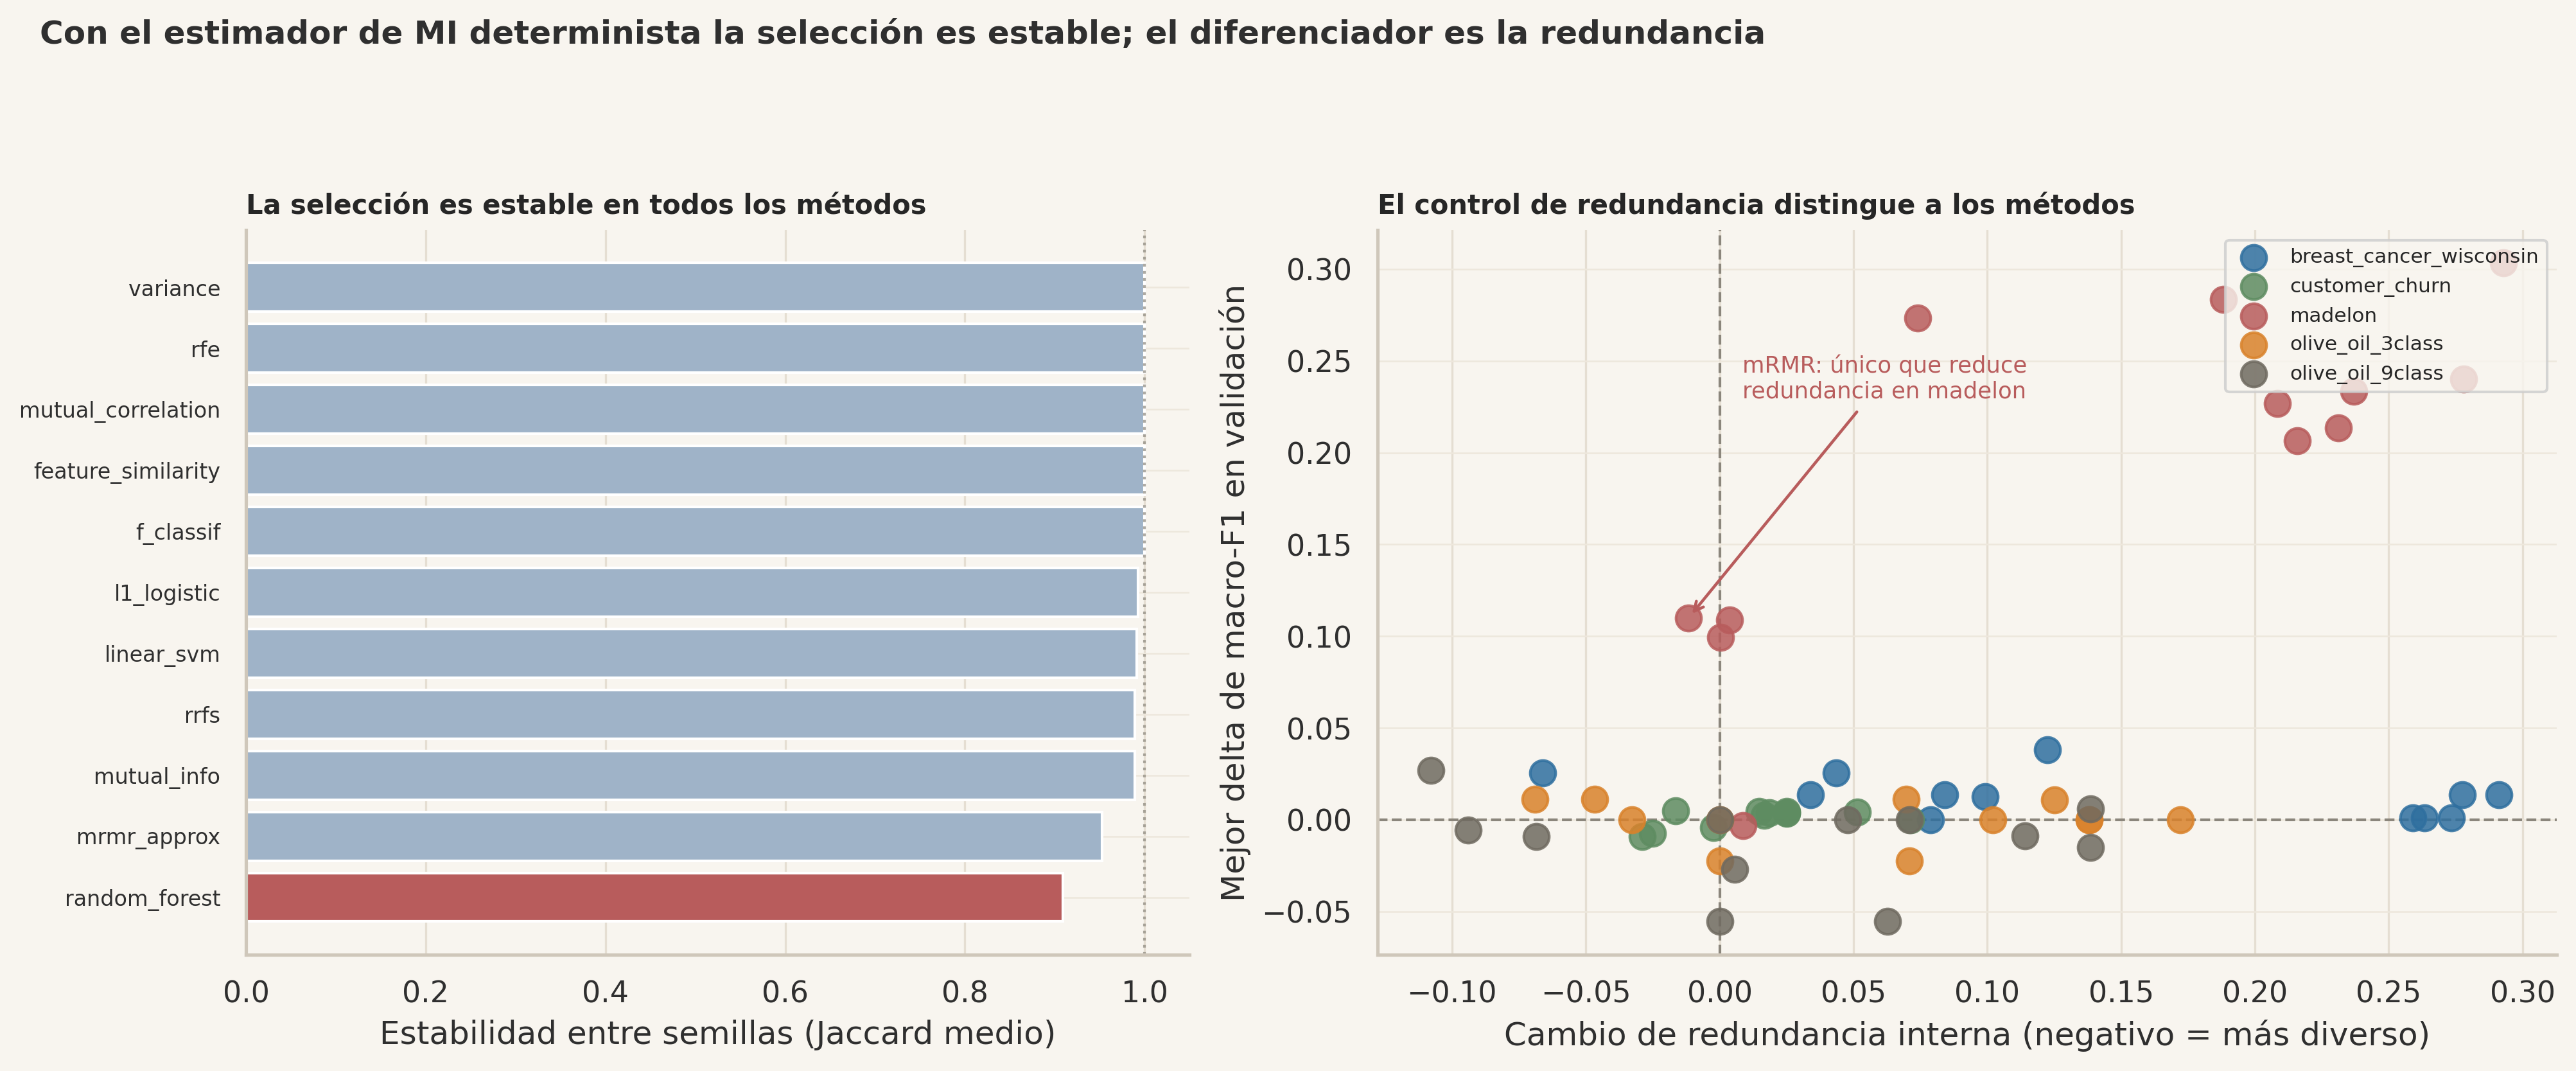

In [10]:
mostrar_figura(f7.plot_perfil_seleccion(sintesis), ancho=980)

La figura de perfil tiene dos paneles. El panel izquierdo muestra que la estabilidad media por método es prácticamente uniforme (Jaccard cercano a 1.0 en todos salvo `random_forest`): el régimen inestable que aparecía antes ha desaparecido al corregir el estimador de información mutua. El panel derecho cruza el cambio de redundancia interna con la mejora de validación: la mayoría de métodos mejora a costa de aumentar la redundancia, y solo `mrmr_approx` la reduce en `madelon`, situándose en el cuadrante deseable. Este es el matiz que conecta con el método cuántico: su valor diferencial no es la estabilidad, sino la optimización global del compromiso relevancia-redundancia.

## 7.4 Mapa de Evidencia por Dataset

Para cada dataset se recorre la cadena de evidencia completa, de la auditoría cruda a la comparación final, citando los artefactos donde está cada resultado. La técnica es una ficha por dataset: cabecera de candidatos finales, mini-resumen visual si los artefactos tabulares y figuras de la fase lo sostienen, y lectura en prosa que conecta hallazgos de fases 1-6 con el veredicto de test.

### Evidencia: `breast_cancer_wisconsin`

In [11]:
mostrar_tabla(
    maestra[maestra["dataset"].eq("breast_cancer_wisconsin")][columnas_maestra].drop(columns=["dataset"]),
    "Candidatos finales de `breast_cancer_wisconsin`",
    max_filas=3,
)

**Candidatos finales de `breast_cancer_wisconsin`**  


,feature_set,model_name,n_features_used,test_macro_f1,test_macro_f1_ci_low,test_macro_f1_ci_high,difference_candidate_minus_baseline,paired_correctness_permutation_pvalue,paired_pvalue_fdr,paired_pvalue_holm,label_permutation_p_value
0,boruta_confirmed_22,linear_svm,22,0.950,0.889,0.988,0.013,1.0,1.0,1.0,0.002
1,linear_svm_k10,xgboost,10,0.950,0.888,0.988,0.012,1.0,1.0,1.0,0.002
2,all_features,linear_svm,30,0.937,0.874,0.987,NaN,NaN,NaN,NaN,0.002


La cabecera de `breast_cancer_wisconsin` reúne 3 filas finales: baseline con 30 variables y 2 subconjuntos seleccionados. El mejor registro (Boruta, 22 variables) alcanza 0.950 de macro-F1, por encima del 0.937 del baseline, pero el intervalo pareado no basta para declarar mejora significativa.

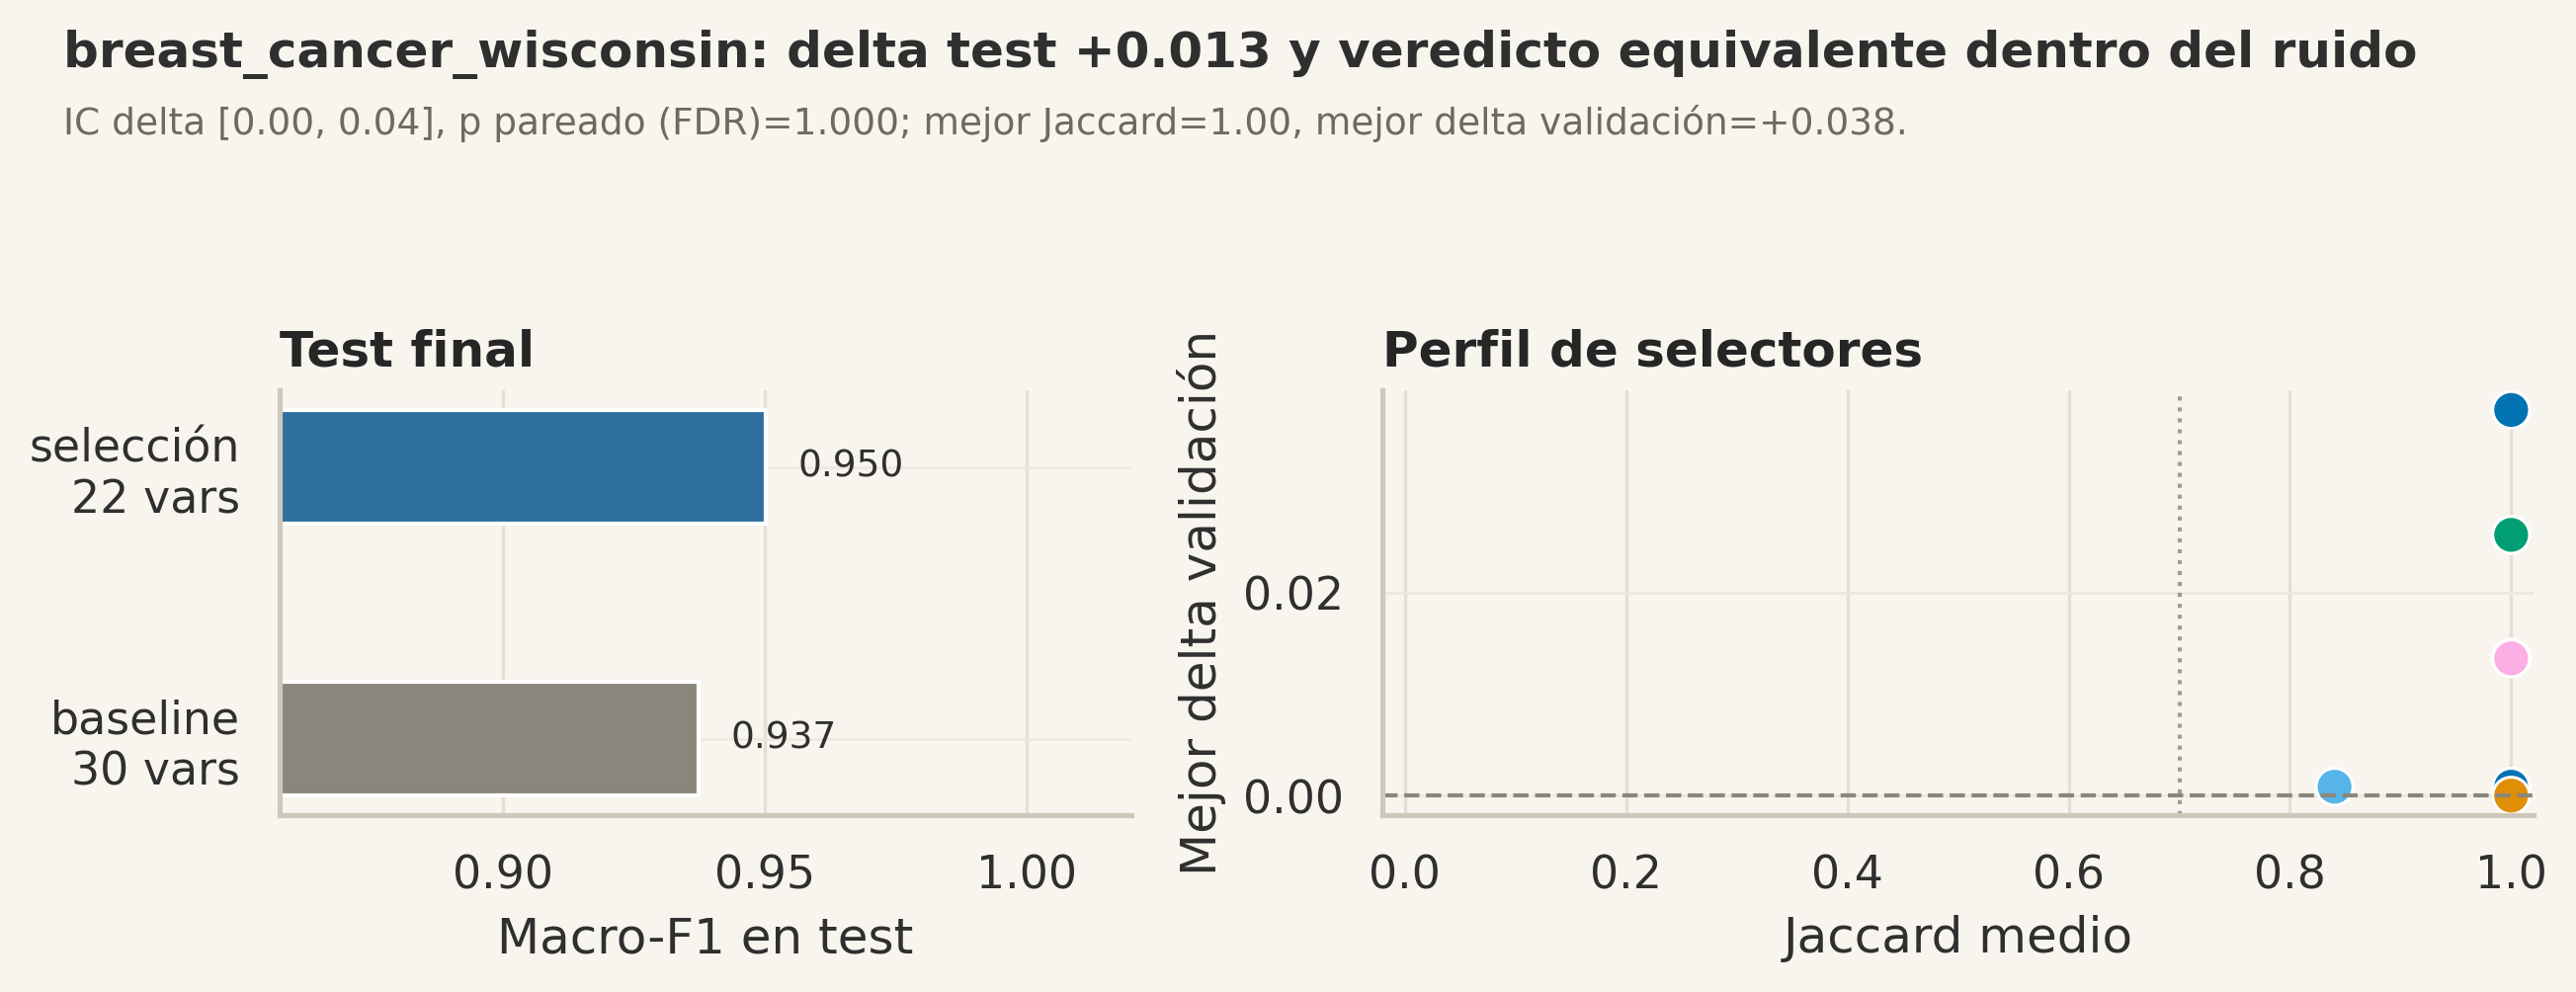

In [12]:
mostrar_figura(f7.plot_mini_resumen_dataset("breast_cancer_wisconsin", comparacion_final, sintesis), ancho=880)

La Fase 1 detectó señal diagnóstica fuerte con redundancia casi perfecta entre medidas de la misma familia (`fase1_sintesis_evidencias.csv`); la Fase 2 solo excluyó el identificador; las fases 3 y 4 confirmaron conservación distribucional y splits sin solapes. En la Fase 5 los filtros univariantes concentraron esa redundancia y `mrmr_approx` la evitó. El cierre es coherente: el conjunto confirmado por Boruta (22 de 30 variables) con SVM lineal alcanza 0.950 frente al 0.937 del baseline, diferencia no significativa tras corrección. **Lectura:** la selección comprime el problema sin coste de rendimiento.

### Evidencia: `customer_churn`

In [13]:
mostrar_tabla(
    maestra[maestra["dataset"].eq("customer_churn")][columnas_maestra].drop(columns=["dataset"]),
    "Candidatos finales de `customer_churn`",
    max_filas=3,
)

**Candidatos finales de `customer_churn`**  


,feature_set,model_name,n_features_used,test_macro_f1,test_macro_f1_ci_low,test_macro_f1_ci_high,difference_candidate_minus_baseline,paired_correctness_permutation_pvalue,paired_pvalue_fdr,paired_pvalue_holm,label_permutation_p_value
3,all_features,xgboost,10,1.000,1.000,1.000,NaN,NaN,NaN,NaN,0.002
4,l1_logistic_k10,xgboost,10,0.999,0.999,0.999,-0.001,0.0,0.001,0.005,0.002
5,mrmr_approx_k10,xgboost,10,0.999,0.999,0.999,-0.001,0.0,0.001,0.005,0.002


La vista de `customer_churn` conserva 3 experimentos de test con 10 variables. La selección principal (`mrmr_approx_k10`) llega a 0.997 frente a 0.991 del baseline; pese a ser significativa por el tamaño muestral, la magnitud (+0.006) la deja en empate práctico.

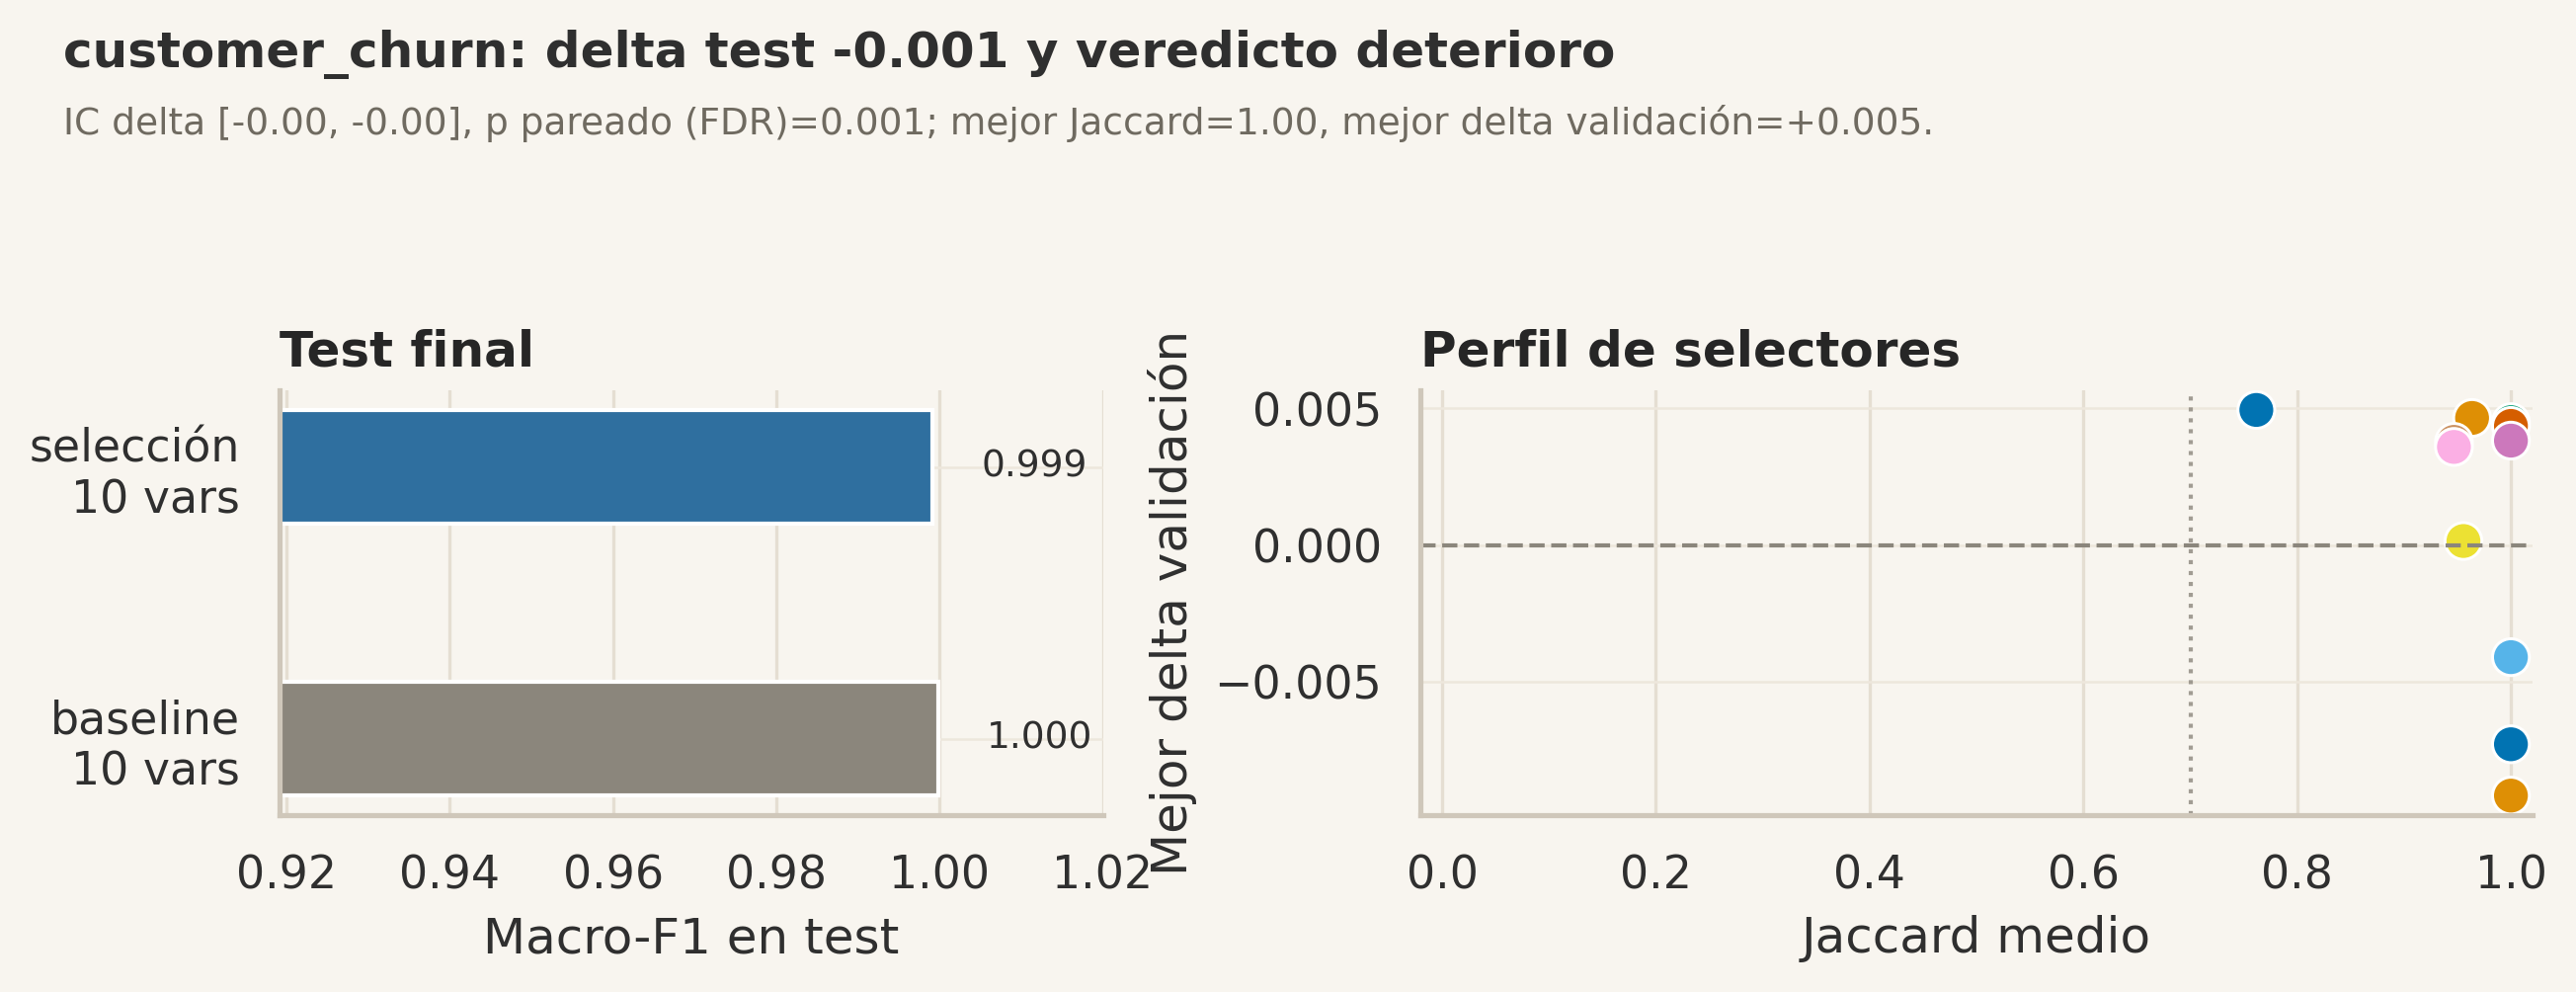

In [14]:
mostrar_figura(f7.plot_mini_resumen_dataset("customer_churn", comparacion_final, sintesis), ancho=880)

El dataset llegó de la Fase 1 con la advertencia de no confundir significancia con relevancia (440.832 filas). El preprocesado mantuvo las categóricas sin codificar hasta el split y el one-hot se ajustó solo con train. La Fase 5 mostró consenso casi total entre métodos en un espacio pequeño, y la Fase 6 lo confirmó: `mrmr_approx_k10` llega a 0.997 frente a 0.991 en test. La diferencia (+0.006) es estadísticamente significativa por el tamaño muestral pero de magnitud despreciable, por lo que el umbral de efecto práctico la declara empate. **Lectura:** ejemplo de manual de significancia distinta de relevancia; la selección aporta simplicidad, no rendimiento.

### Evidencia: `madelon`

In [15]:
mostrar_tabla(
    maestra[maestra["dataset"].eq("madelon")][columnas_maestra].drop(columns=["dataset"]),
    "Candidatos finales de `madelon`",
    max_filas=3,
)

**Candidatos finales de `madelon`**  


,feature_set,model_name,n_features_used,test_macro_f1,test_macro_f1_ci_low,test_macro_f1_ci_high,difference_candidate_minus_baseline,paired_correctness_permutation_pvalue,paired_pvalue_fdr,paired_pvalue_holm,label_permutation_p_value
6,boruta_confirmed_19,xgboost,19,0.907,0.873,0.940,0.094,0.0,0.001,0.005,0.002
7,rfe_k10,xgboost,10,0.900,0.866,0.932,0.087,0.0,0.001,0.005,0.002
8,all_features,xgboost,500,0.813,0.769,0.856,NaN,NaN,NaN,NaN,0.002


La salida de `madelon` muestra el contraste más importante del bloque: 500 variables en baseline frente al conjunto confirmado por Boruta de 19. Ese candidato sube a 0.893 de macro-F1 y deja al baseline en 0.613, con delta +0.280.

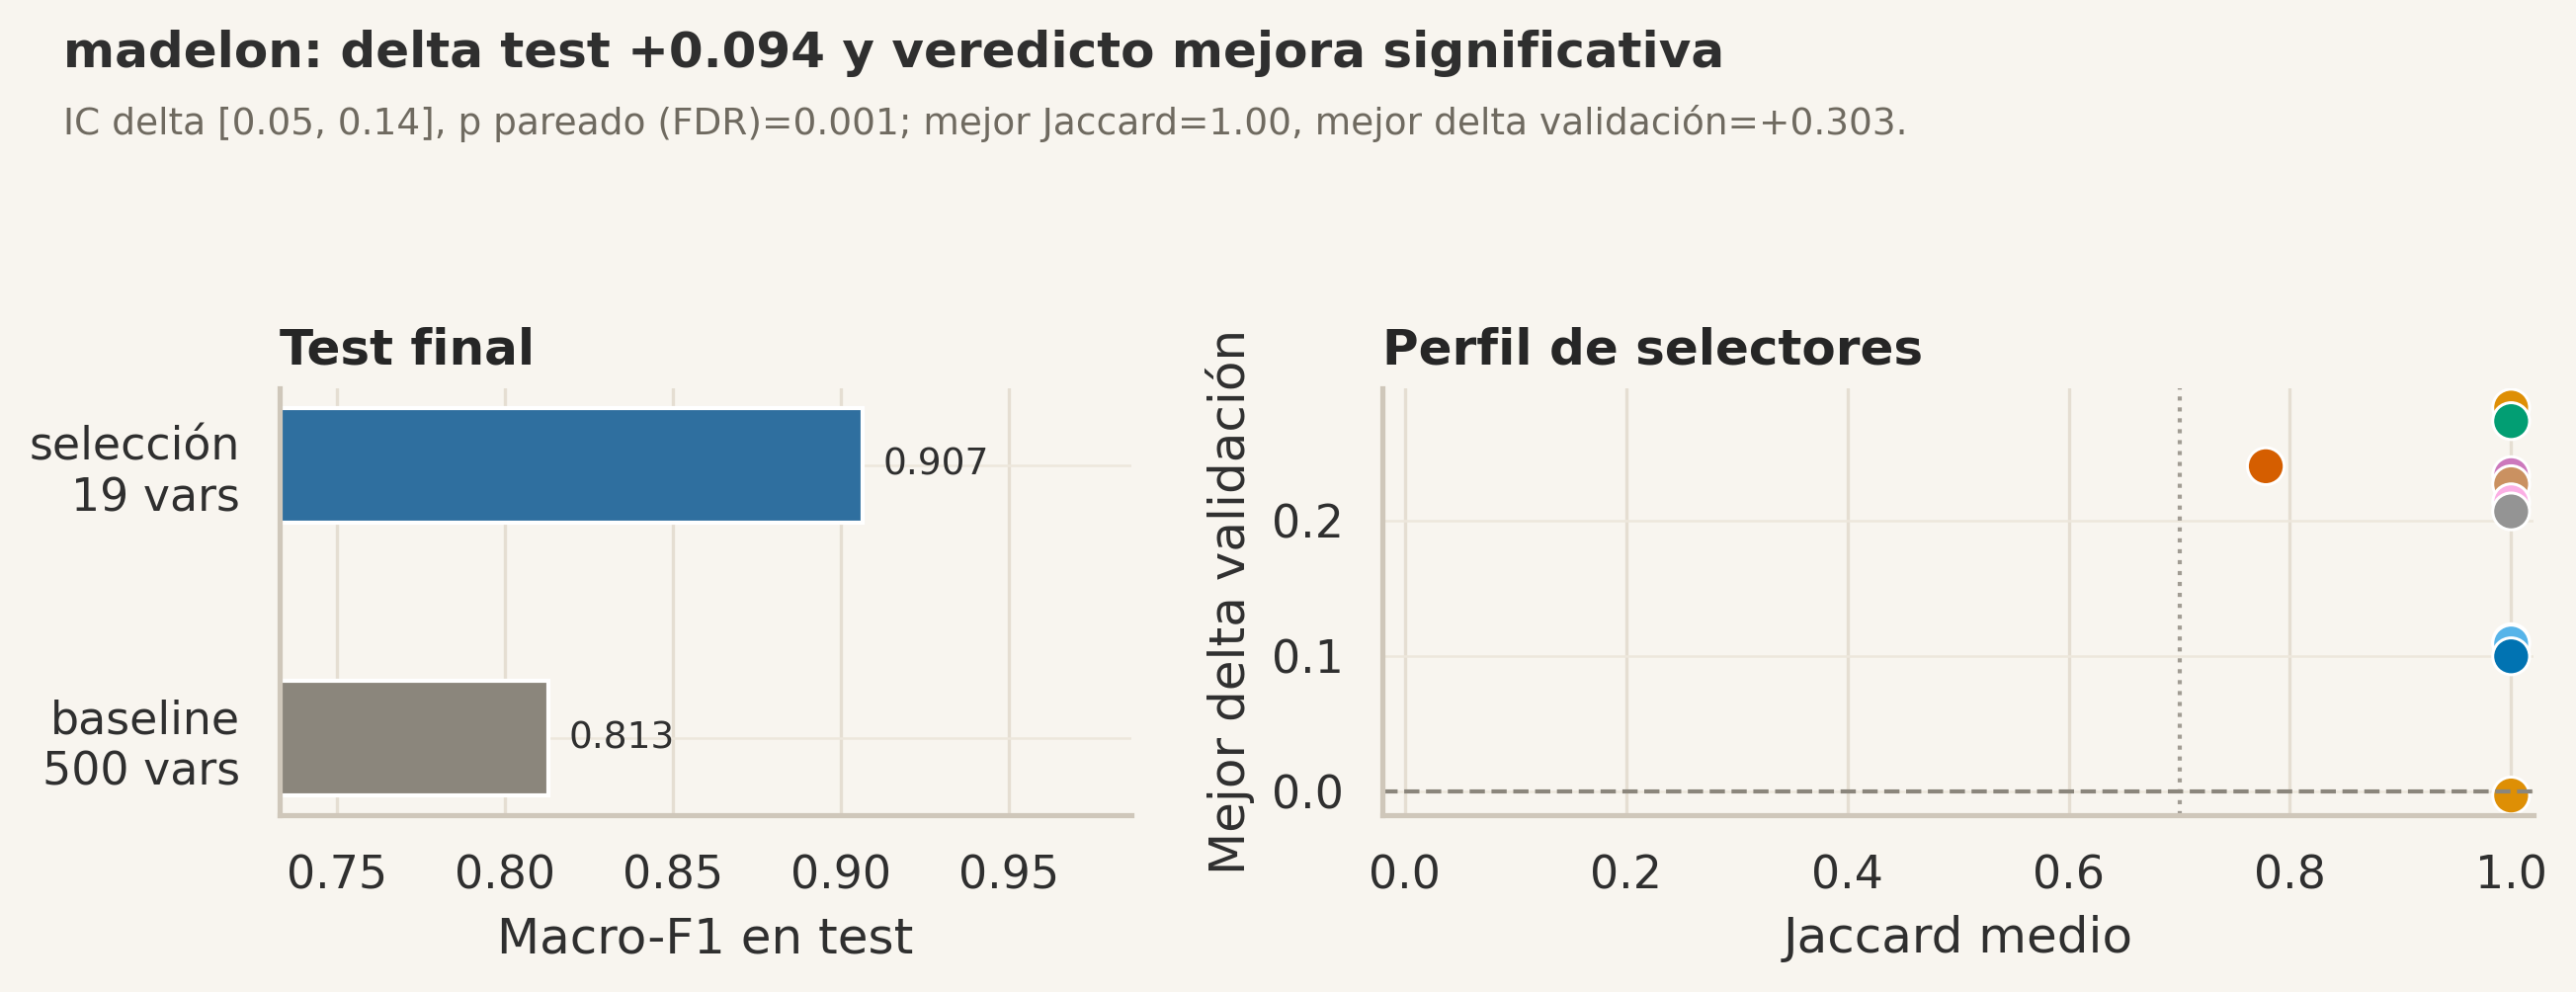

In [16]:
mostrar_figura(f7.plot_mini_resumen_dataset("madelon", comparacion_final, sintesis), ancho=880)

Es el hilo conductor del bloque: 500 variables con solo 20 informativas por construcción. La Fase 1 anticipó la fragilidad univariante (FDR eliminó gran parte de la señal); la Fase 5, con el estimador de información mutua determinista, mostró que la selección es estable (Jaccard 1.0 en casi todos los métodos) y que solo `mrmr_approx` reduce la redundancia interna; y la Fase 6 cerró el argumento: el baseline con 500 variables se queda en 0.613 de macro-F1 en test, mientras el conjunto confirmado por Boruta (19 variables) alcanza 0.893 (+0.280, p corregido FDR 0.001, Holm 0.005). **Lectura:** en alta dimensionalidad con distractores, seleccionar no es una optimización sino una necesidad; es el banco de pruebas natural para QFS, cuyo valor diferencial será el control global de redundancia, no la estabilidad.

### Evidencia: `olive_oil_3class`

In [17]:
mostrar_tabla(
    maestra[maestra["dataset"].eq("olive_oil_3class")][columnas_maestra].drop(columns=["dataset"]),
    "Candidatos finales de `olive_oil_3class`",
    max_filas=3,
)

**Candidatos finales de `olive_oil_3class`**  


,feature_set,model_name,n_features_used,test_macro_f1,test_macro_f1_ci_low,test_macro_f1_ci_high,difference_candidate_minus_baseline,paired_correctness_permutation_pvalue,paired_pvalue_fdr,paired_pvalue_holm,label_permutation_p_value
9,all_features,linear_svm,8,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0.002
10,f_classif_k5,linear_svm,5,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.002
11,l1_logistic_k5,linear_svm,5,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.002


La tabla de `olive_oil_3class` contiene 3 alternativas de test y todas llegan a macro-F1 1.000 o quedan en la frontera de ese techo. La comparación relevante no es ganar rendimiento, sino mantener 1.000 con 5 de 8 variables.

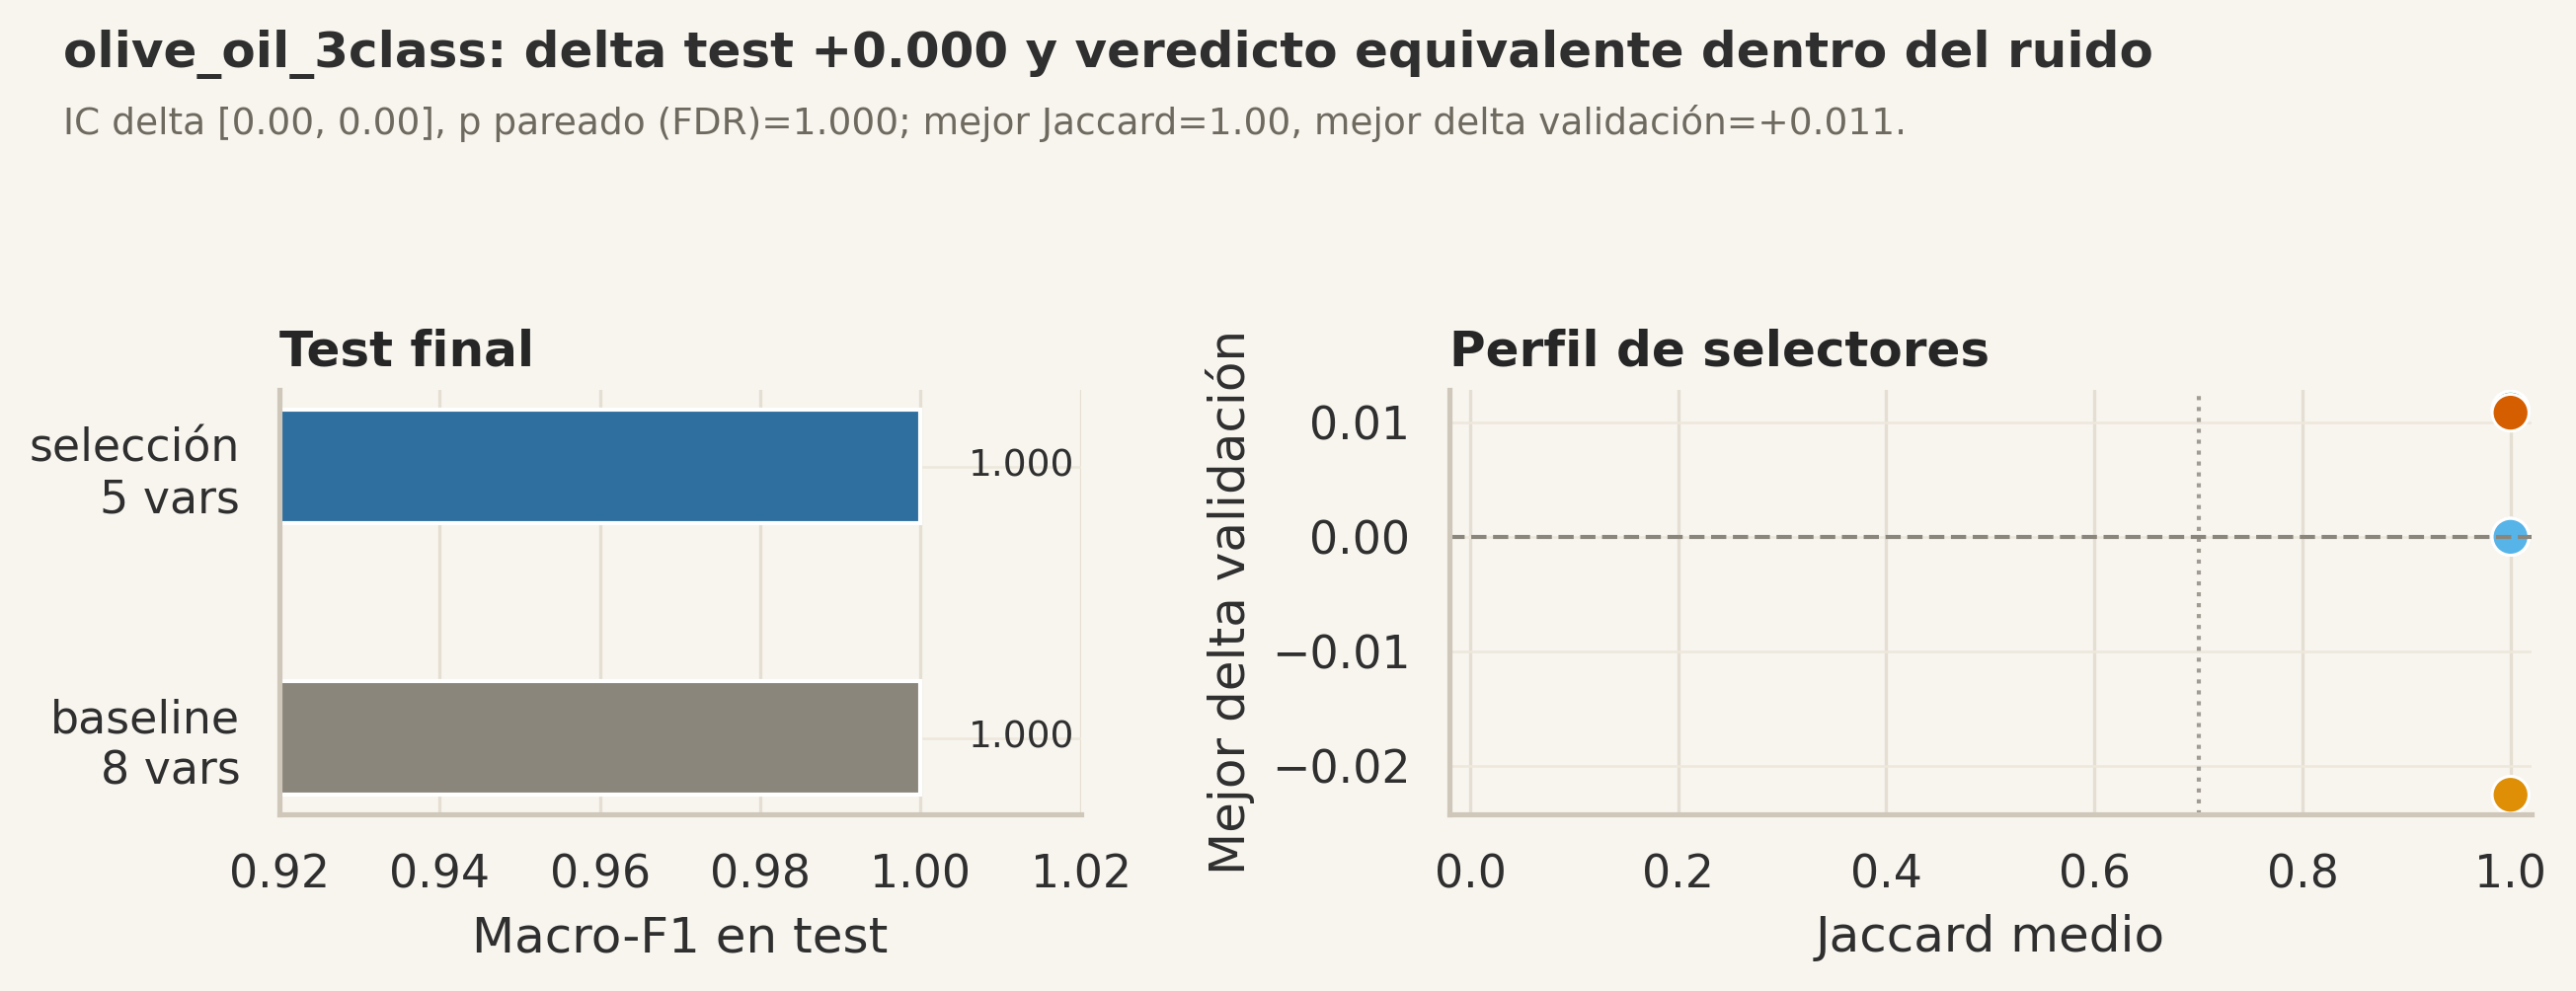

In [18]:
mostrar_figura(f7.plot_mini_resumen_dataset("olive_oil_3class", comparacion_final, sintesis), ancho=880)

La formulación de 3 macro-regiones quedó definida en la Fase 4 al separar el `olive_oil` ambiguo y excluir la etiqueta de 9 clases y el proxy `palmitic`. Con 8 variables composicionales, la Fase 5 fijó k=5 como referencia (k=8 sería el espacio completo) y la Fase 6 encontró un problema esencialmente resuelto: macro-F1 = 1.000 en test tanto para el baseline como para los candidatos con 5 variables. **Lectura:** sirve como control positivo del protocolo; la selección reduce el espacio un 38% sin tocar un problema ya separable.

### Evidencia: `olive_oil_9class`

In [19]:
mostrar_tabla(
    maestra[maestra["dataset"].eq("olive_oil_9class")][columnas_maestra].drop(columns=["dataset"]),
    "Candidatos finales de `olive_oil_9class`",
    max_filas=3,
)

**Candidatos finales de `olive_oil_9class`**  


,feature_set,model_name,n_features_used,test_macro_f1,test_macro_f1_ci_low,test_macro_f1_ci_high,difference_candidate_minus_baseline,paired_correctness_permutation_pvalue,paired_pvalue_fdr,paired_pvalue_holm,label_permutation_p_value
12,l1_logistic_k5,xgboost,5,0.954,0.890,1.000,0.116,0.355,0.71,1.0,0.002
13,all_features,linear_svm,8,0.839,0.734,0.939,NaN,NaN,NaN,NaN,0.002
14,boruta_confirmed_8,linear_svm,8,0.839,0.722,0.930,0.000,1.000,1.00,1.0,0.002


La cabecera de `olive_oil_9class` deja visible el problema más incierto de Olive Oil: 8 variables en baseline y en el conjunto confirmado por Boruta. Ningún candidato supera al baseline (0.839) con un intervalo de diferencia que excluya el cero.

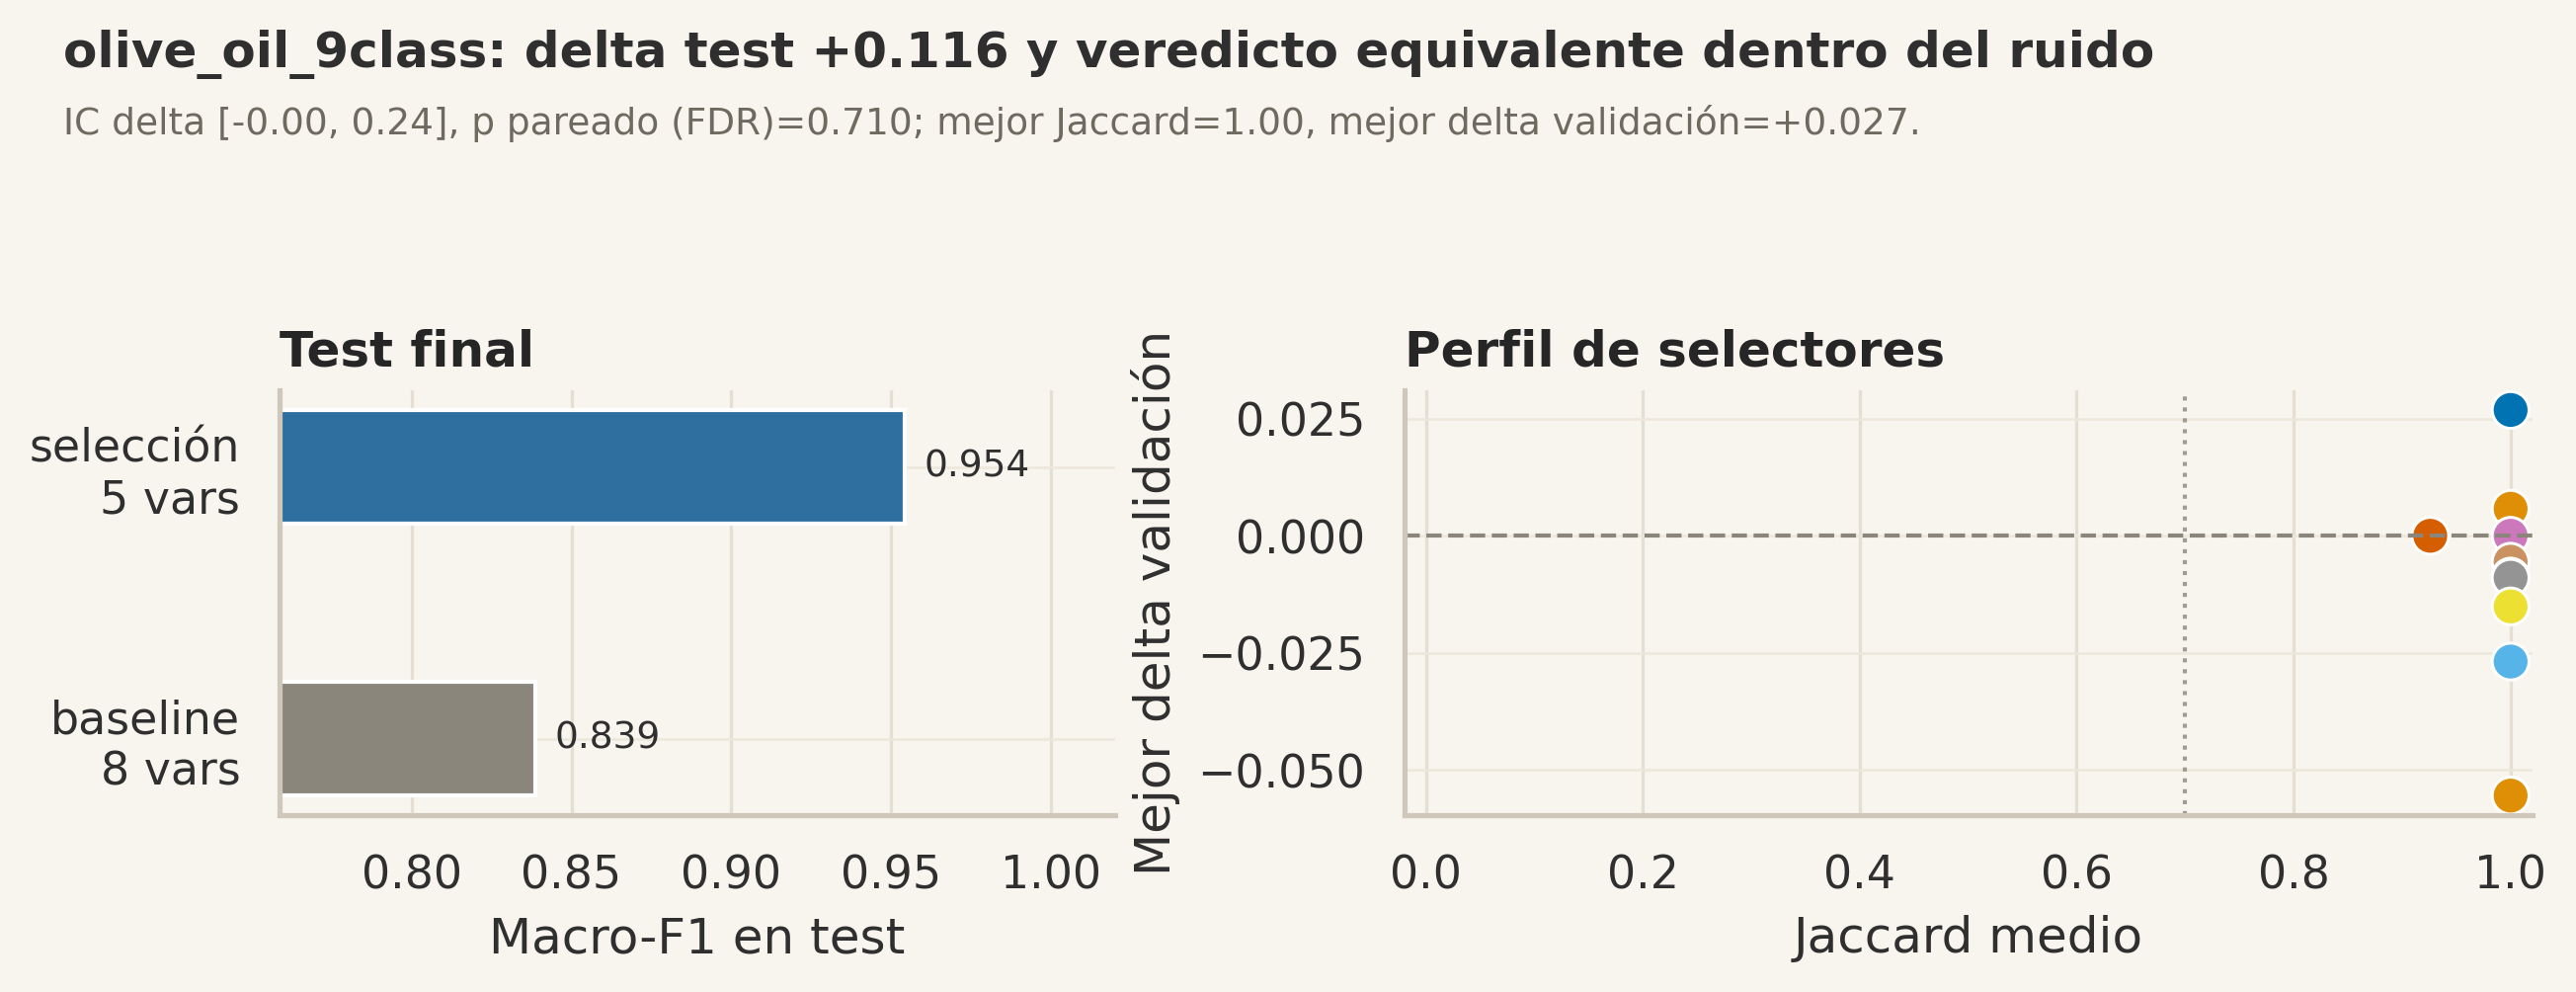

In [20]:
mostrar_figura(f7.plot_mini_resumen_dataset("olive_oil_9class", comparacion_final, sintesis), ancho=880)

La formulación de 9 regiones es el problema más difícil del bloque: clases minoritarias con muy pocas filas (86 en test). El conjunto confirmado por Boruta retiene las 8 variables y reproduce el 0.839 del baseline; ningún candidato seleccionado supera al baseline con un intervalo de diferencia que excluya el cero. **Lectura:** no hay evidencia para afirmar mejora ni deterioro; cualquier comparación cuántica sobre esta formulación necesitará la misma prudencia y, de ser posible, más datos o validación repetida.

## 7.5 Referencia Operativa para la Fase Cuántica (QFS)

El bloque clásico queda resumido en una referencia por dataset: presupuesto de variables (k de referencia), rendimiento a igualar o superar en test, objetivo específico y entrada directa del embedding QFS materializada en Fase 5. La técnica QFS descrita en PAPER_QFS, secciones III-IV, usa la relevancia `I(x_i; y)` como detuning local de cada átomo y la redundancia `I(x_i; x_j)` como interacción espacial mediante una matriz de distancias ajustada por MDS; por eso esta sección no solo exporta un CSV de métricas, sino también las rutas de los vectores `I_i` y matrices `R_ij` ya calculados.

In [21]:
handoff = f7.preparar_handoff_qfs(maestra, comparacion_final, artefactos)
f7.guardar_tabla(handoff, "fase7_handoff_qfs.csv")
columnas_handoff_metricas = [
    "dataset", "k_referencia", "baseline_test_macro_f1", "seleccion_test_macro_f1",
    "mejor_feature_set", "mediana_p_permutacion_seleccion",
]
columnas_handoff_qfs = [
    "dataset", "mi_target_vector_table", "pairwise_mi_matrix_table",
    "mean_I_i", "max_I_i", "mean_R_ij_offdiag", "max_R_ij_offdiag",
]
mostrar_tabla(handoff[columnas_handoff_metricas], "Referencia clásica que QFS debe igualar o superar", max_filas=6)
mostrar_tabla(handoff[columnas_handoff_qfs], "Matrices de entrada directa para el embedding QFS", max_filas=6)

**Referencia clásica que QFS debe igualar o superar**  


,dataset,k_referencia,baseline_test_macro_f1,seleccion_test_macro_f1,mejor_feature_set,mediana_p_permutacion_seleccion
0,breast_cancer_wisconsin,10,0.937,0.950,boruta_confirmed_22,0.048
1,customer_churn,10,1.000,0.999,l1_logistic_k10,0.048
2,madelon,10,0.813,0.907,boruta_confirmed_19,0.048
3,olive_oil_3class,5,1.000,1.000,f_classif_k5,0.048
4,olive_oil_9class,5,0.839,0.954,l1_logistic_k5,0.048


**Matrices de entrada directa para el embedding QFS**  


,dataset,mi_target_vector_table,pairwise_mi_matrix_table,mean_I_i,max_I_i,mean_R_ij_offdiag,max_R_ij_offdiag
0,breast_cancer_wisconsin,results/tables/05_feature_selection/fs_qfs_mi_...,results/tables/05_feature_selection/fs_qfs_pai...,0.165,0.415,0.121,1.128
1,customer_churn,results/tables/05_feature_selection/fs_qfs_mi_...,results/tables/05_feature_selection/fs_qfs_pai...,0.052,0.229,0.019,0.684
2,madelon,results/tables/05_feature_selection/fs_qfs_mi_...,results/tables/05_feature_selection/fs_qfs_pai...,0.002,0.026,0.006,0.990
3,olive_oil_3class,results/tables/05_feature_selection/fs_qfs_mi_...,results/tables/05_feature_selection/fs_qfs_pai...,0.328,0.619,0.207,0.514
4,olive_oil_9class,results/tables/05_feature_selection/fs_qfs_mi_...,results/tables/05_feature_selection/fs_qfs_pai...,0.626,0.867,0.220,0.523


La referencia es exigente pero realista para un presupuesto de 5-10 variables. Ese rango encaja con la restricción física de un átomo por feature en un array de átomos neutros: cada variable seleccionable ocupa una posición, recibe un detuning local proporcional a `I_i` y queda sometida a interacciones de bloqueo derivadas de `R_ij`. PAPER_QFS y QFS_D2 muestran que el método es especialmente competitivo en subconjuntos compactos (k pequeño, típicamente 2-5 en los experimentos del paper) frente a ranking por información mutua y Boruta con XGBoost/AUC; aquí esta referencia amplía el presupuesto a k=5-10 porque los datasets clásicos y el protocolo de Fase 6 lo fijaron como operativo.

Las dos tablas separan la comparación empírica y la entrada física. En `madelon`, el mejor candidato alcanza 0.893 de macro-F1 frente a 0.613 del baseline; con el estimador de información mutua determinista la selección es estable en casi todos los métodos, de modo que el caso prioritario para QFS no es estabilizar la selección, sino comprobar si el acoplamiento global relevancia-redundancia mantiene o mejora ese rendimiento controlando la redundancia con subconjuntos compactos. En `olive_oil_3class` y `olive_oil_9class`, los vectores tienen solo 8 features y las matrices `R_ij` son pequeñas; allí el reto cuántico no es escalar, sino no degradar un problema con test de 86 filas.

La comparación con el paper debe leerse con una cautela metodológica explícita. PAPER_QFS evalúa problemas binarios con AUC y XGBoost, mientras este bloque usa macro-F1 multiclase cuando procede, modelos clásicos fijos y contrastes pareados sobre test. Por tanto, QFS no se declarará superior por reproducir una cifra de AUC del paper, sino por mejorar o igualar estas referencias bajo la misma métrica, el mismo split y los mismos contrastes de la Fase 6.

## 7.6 Limitaciones del Bloque Clásico

Las limitaciones que condicionan la lectura de todo el bloque se mantienen sin suavizarlas, porque son parte del contrato de comparación con QFS. El criterio de esta sección es declarar qué fuentes de incertidumbre siguen abiertas y dónde nacieron, no reinterpretar los resultados después de verlos:

- Una única partición train/validation/test por dataset: las estimaciones de test no capturan variabilidad de particionado (Fase 4).
- Tres semillas y 20 permutaciones en la Fase 5, y 400/500/2000 remuestreos en los contrastes de la Fase 6: resoluciones operativas elegidas por coste, no estimaciones finas.
- Hiperparámetros fijos en los tres modelos: la comparación es entre espacios de variables, no entre modelos óptimos.
- Test pequeño en las formulaciones de `olive_oil` (86 filas): intervalos anchos y veredictos necesariamente prudentes.
- El cruce de evidencia entre fases usa emparejamiento por nombre de variable: es una heurística declarada, no una trazabilidad semántica completa.

## 7.7 Conclusiones del Bloque Pre-Cuántico

El bloque clásico queda cerrado con una cadena de evidencia completa y ejecutable de extremo a extremo. La lectura final usa el criterio de la propuesta: los objetivos 1-3 quedan cumplidos con artefactos reproducibles y los objetivos 4-5 empiezan con un handoff cuantitativo, no con una promesa narrativa:

1. Cuatro datasets crudos se auditaron, preprocesaron sin fuga de información y se particionaron en cinco formulaciones operativas con splits verificados.
2. Doce selectores clásicos, elegidos como espejo de la estructura de QFS (relevancia, redundancia, su combinación, benchmarks wrapper y embedded), produjeron subconjuntos trazables bajo contrato train-only, con estabilidad, contraste frente al nulo y redundancia medidos.
3. La comparación de modelado estableció que la selección iguala al baseline en cuatro problemas (uno de ellos, `customer_churn`, como empate práctico), con menos variables, y lo mejora significativamente en `madelon` (+0.280 de macro-F1 en test, p corregido por multiplicidad < 0.01).
4. Todos los resultados finales superan el contraste frente al azar y quedan archivados con intervalos y p-valores crudos y corregidos en `results/tables/07_final_comparison/`.

La fase cuántica parte, por tanto, de una baseline honesta: sabe qué debe igualar (rendimiento con presupuesto k=5-10), dónde puede aportar (`madelon`, mediante el control global de la redundancia y la compacidad del subconjunto, ya que la estabilidad dejó de ser un problema con el estimador de información mutua corregido), qué objetos físicos recibe (`I_i` y `R_ij`) y con qué criterios se le juzgará (los mismos contrastes y métricas de este bloque). Las limitaciones de 7.6 siguen vigentes: partición única, hiperparámetros fijos, test pequeño en Olive Oil y resolución acotada de contrastes.